<a href="https://colab.research.google.com/github/sohan4518/machine-learning/blob/main/ML_lab_all.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

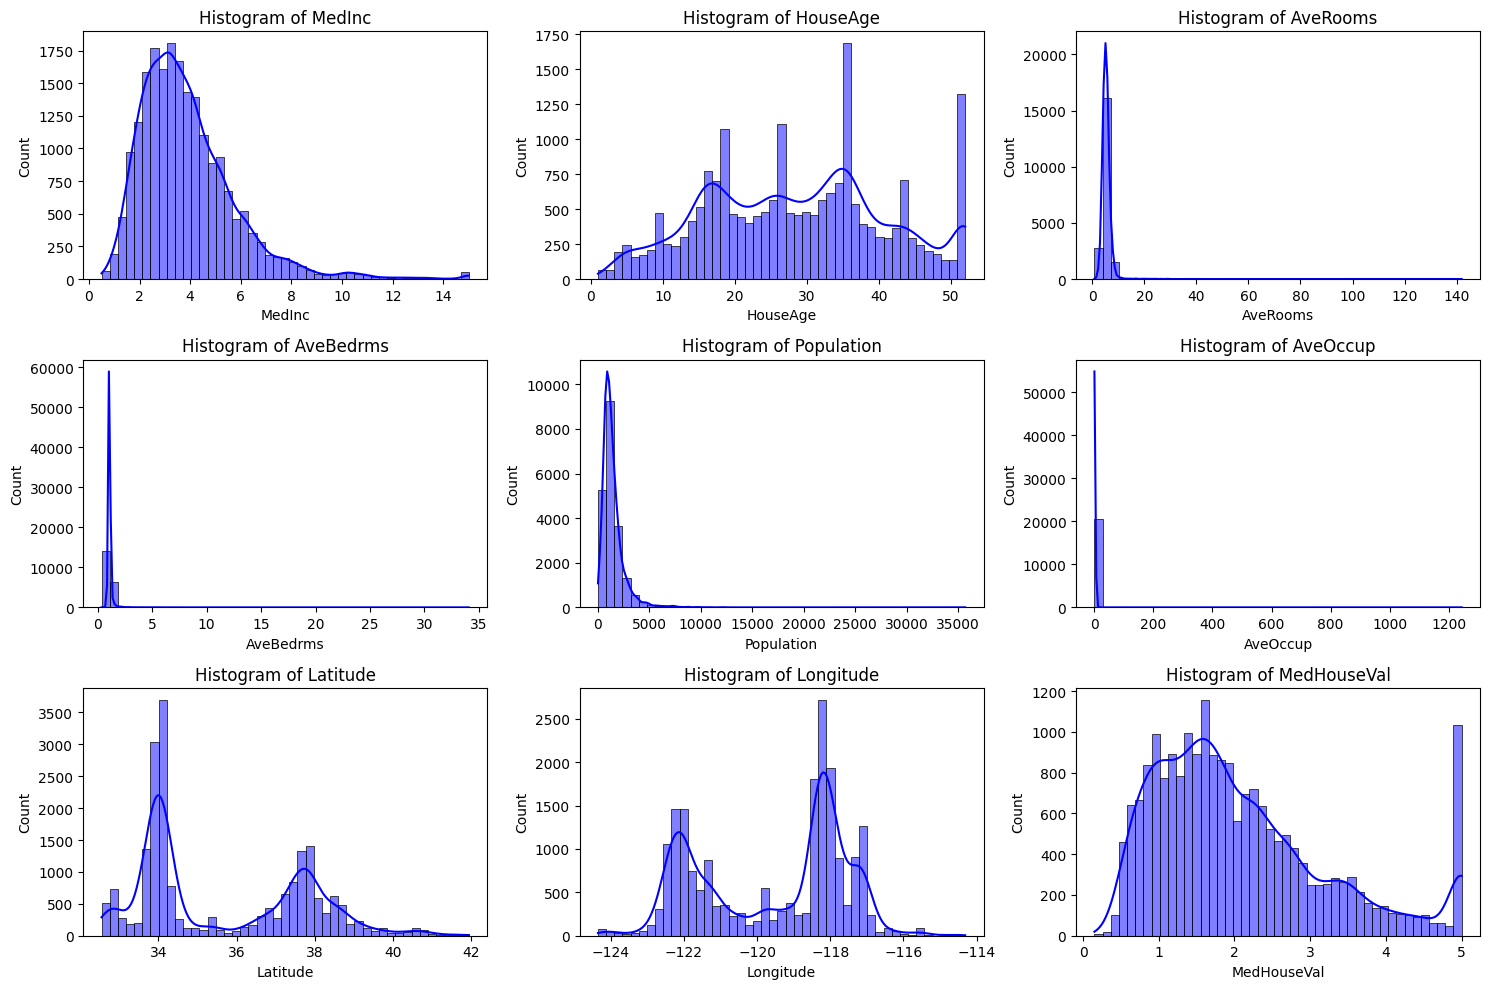

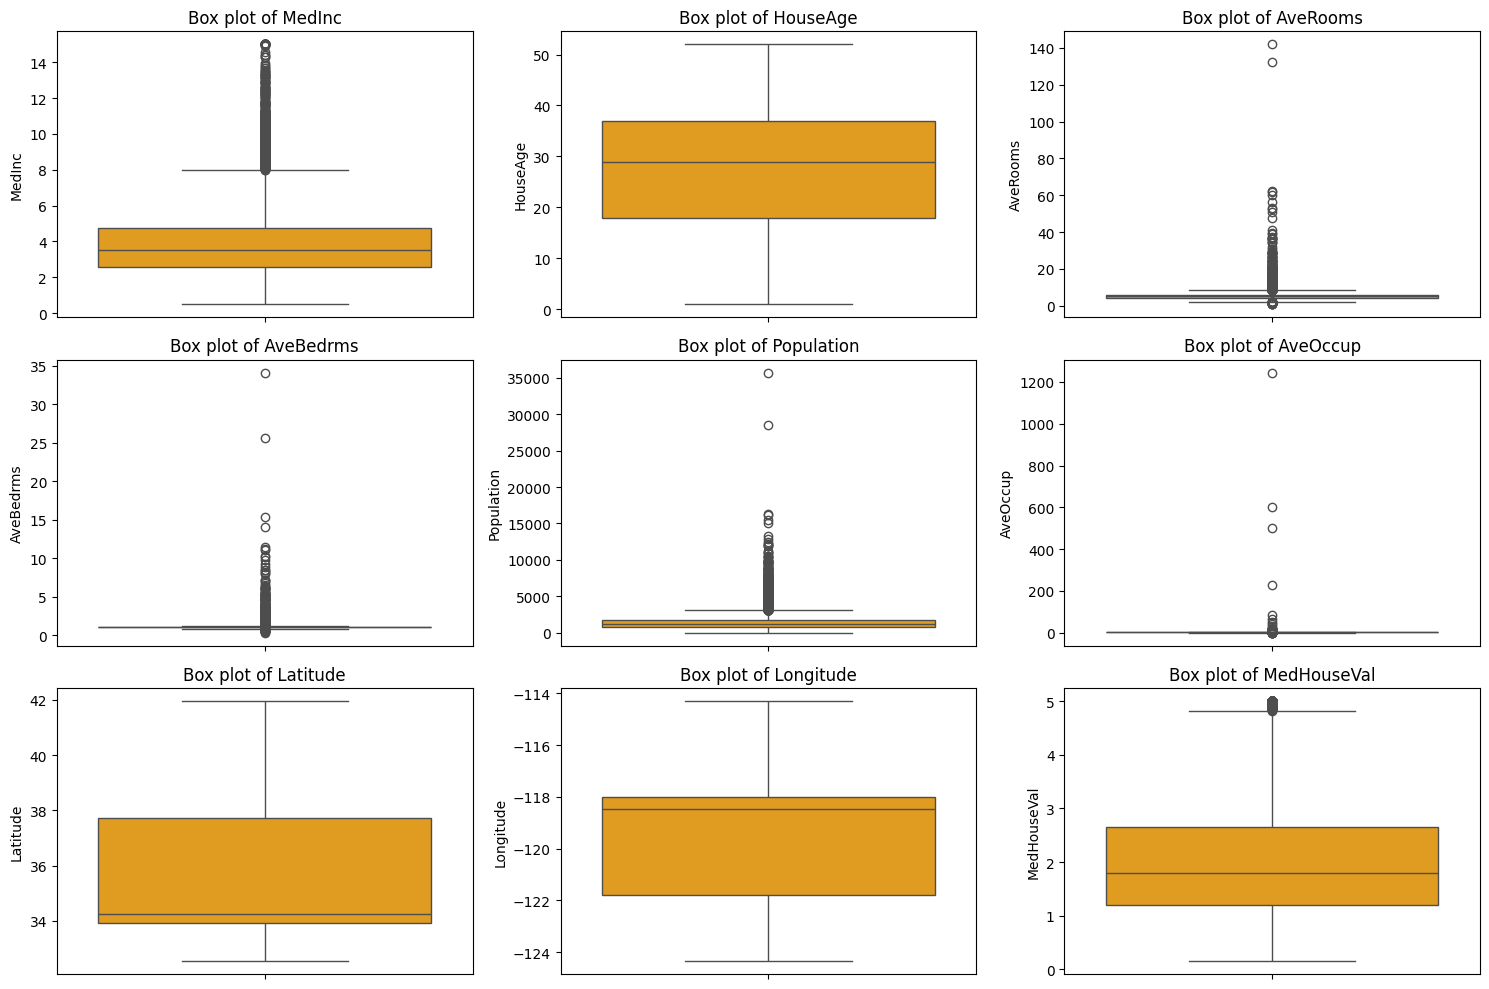

Description of outliers
{'MedInc': 681, 'HouseAge': 0, 'AveRooms': 511, 'AveBedrms': 1424, 'Population': 1196, 'AveOccup': 711, 'Latitude': 0, 'Longitude': 0, 'MedHouseVal': 1071}
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000

In [ ]:
#lab 1
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing(as_frame=True)
housing_df=data.frame
numerical_features=housing_df.select_dtypes(include=[np.number])
numerical_features.head()

plt.figure(figsize=(15,10))
for i,feature in enumerate(numerical_features.columns):
    plt.subplot(3,3,i+1)
    sns.histplot(data=housing_df[feature],kde=True,bins=45,color='blue')
    plt.title(f'Histogram of {feature}')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15,10))
for i,feature in enumerate(numerical_features.columns):
    plt.subplot(3,3,i+1)
    sns.boxplot(data=housing_df[feature],color='orange')
    plt.title(f'Box plot of {feature}')
plt.tight_layout()
plt.show()

print("Description of outliers")
outliers_summary={}
for feature in numerical_features.columns:
    Q1=housing_df[feature].quantile(0.25)
    Q3=housing_df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    outliers=housing_df[(housing_df[feature]<lower_bound) | (housing_df[feature]>upper_bound)]
    outliers_summary[feature] = len(outliers)
print(outliers_summary)
print(housing_df.describe())


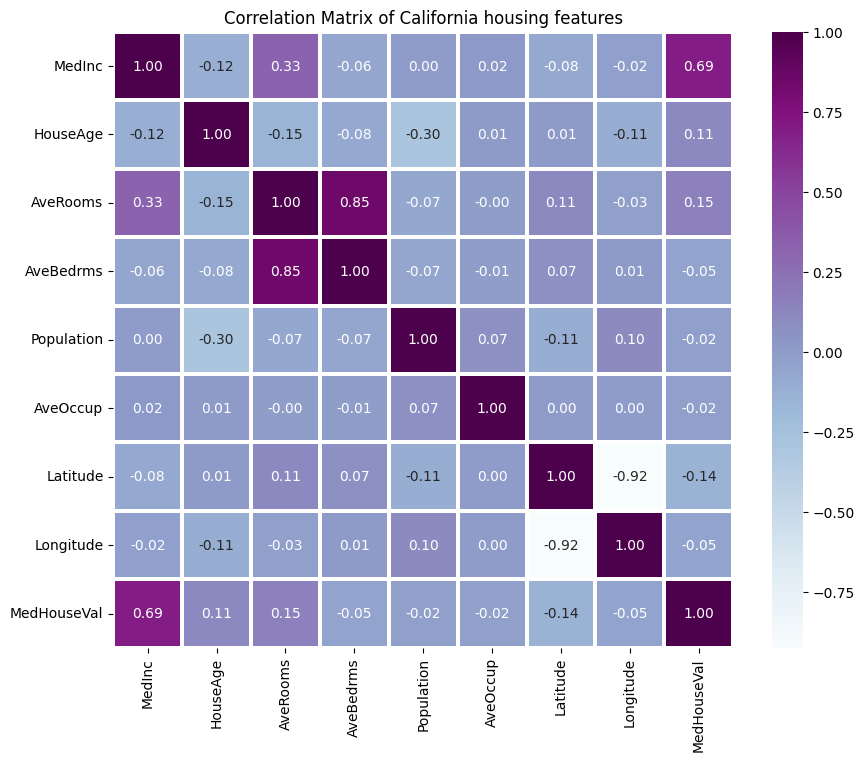

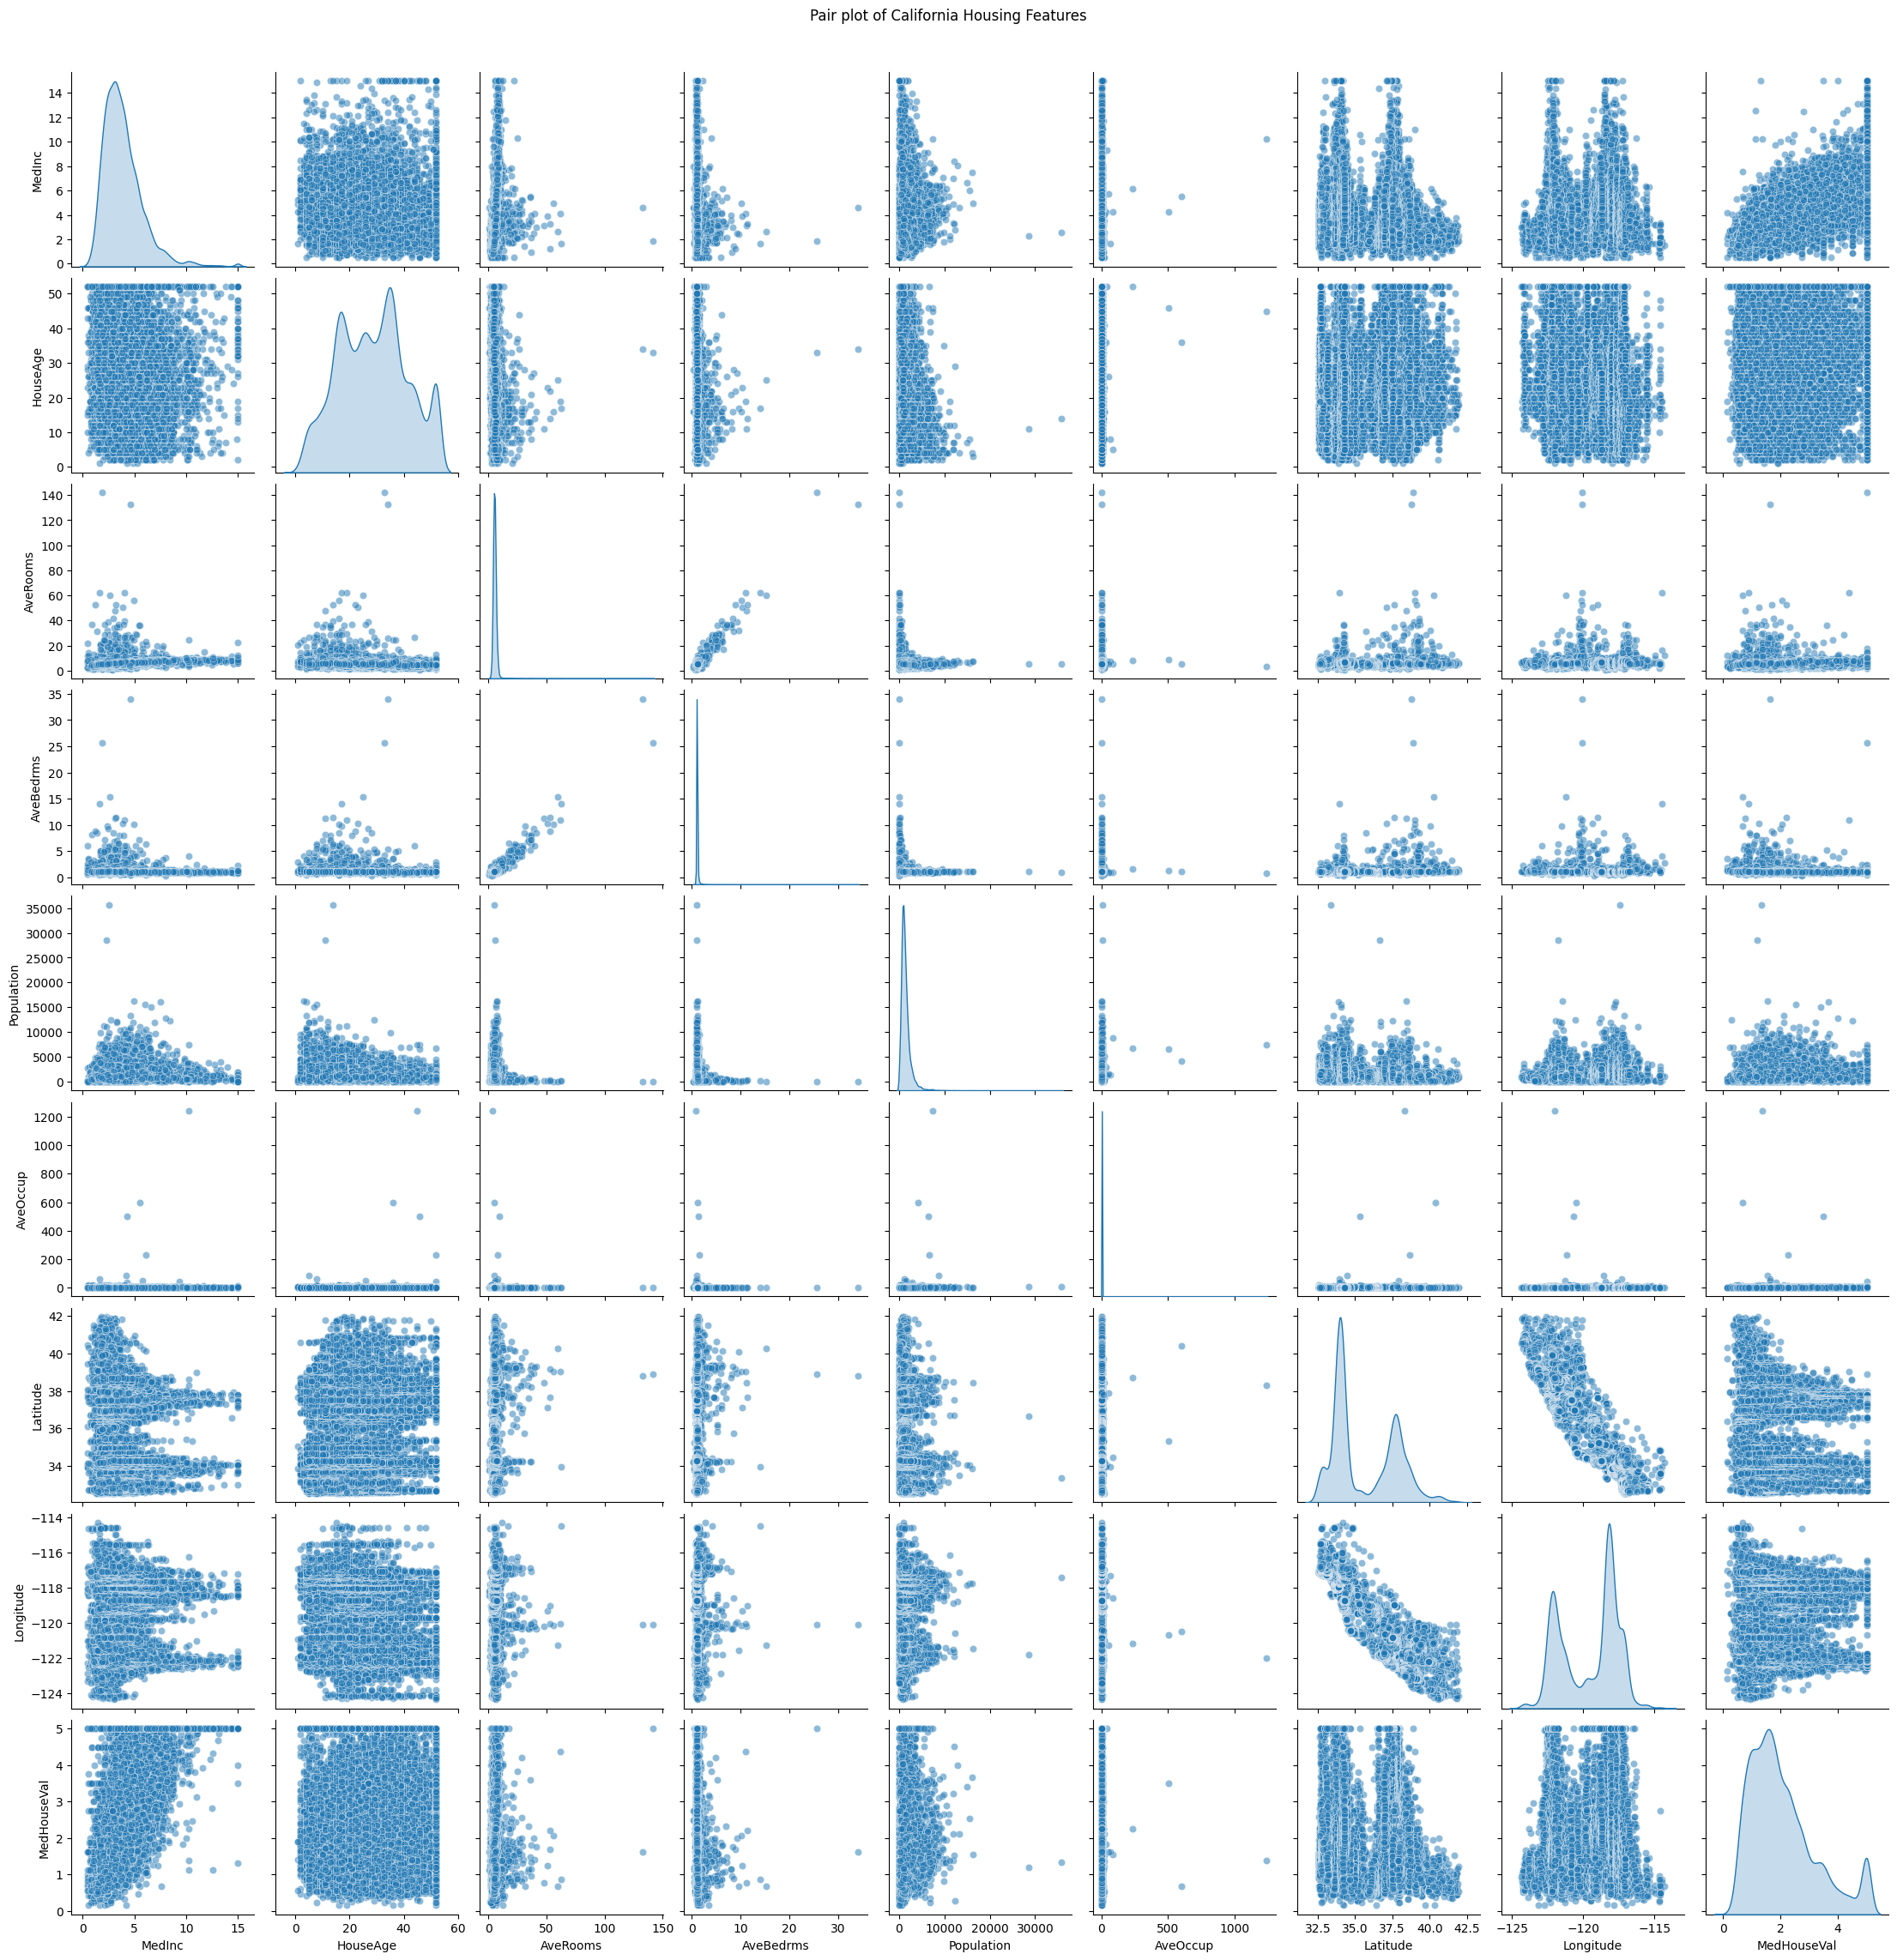

In [ ]:
#lab 2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
california_data=fetch_california_housing(as_frame=True)
data=california_data.frame
correlation_matrix=data.corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix,annot=True,cmap='BuPu',fmt='.2f',linewidths=1.5)
plt.title('Correlation Matrix of California housing features')
plt.show()
sns.pairplot(data,diag_kind='kde',plot_kws={'alpha':0.5})
plt.suptitle('Pair plot of California Housing Features',y=1.02)
plt.show()

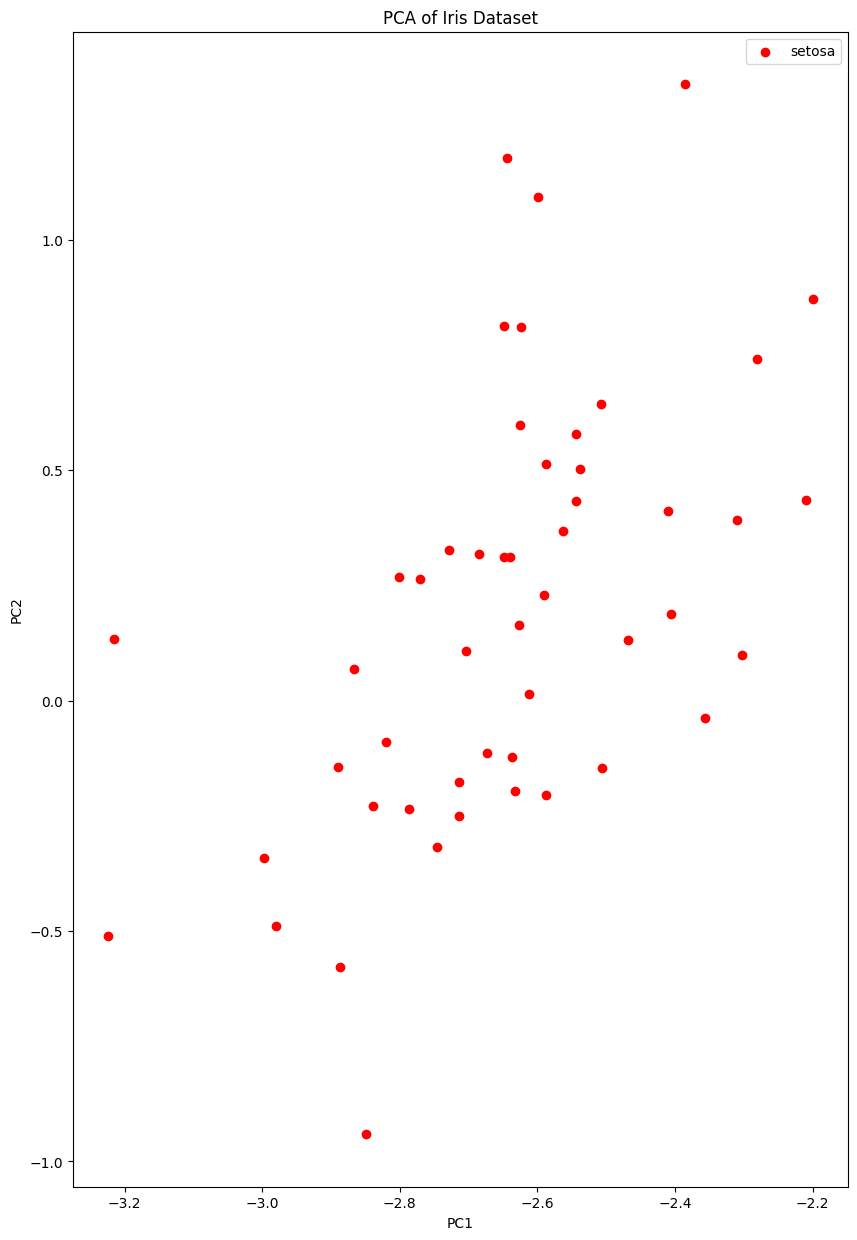

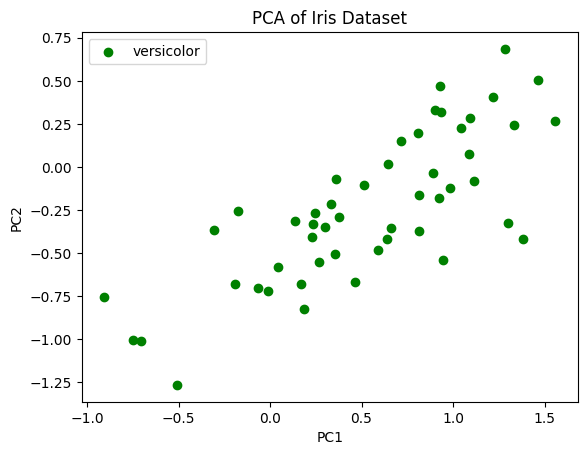

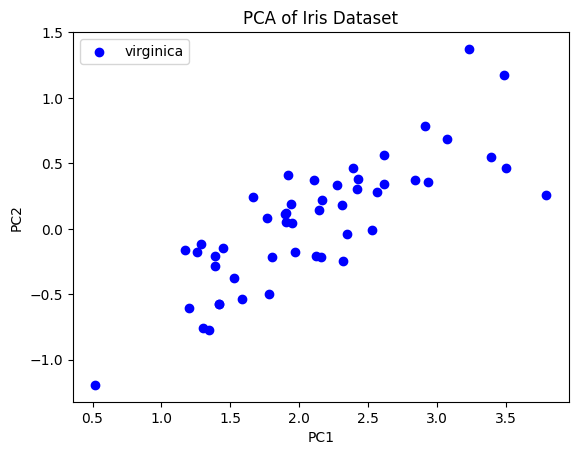

In [ ]:
#lab 3
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
iris=load_iris()
data=iris.data
target=iris.target
label_names=iris.target_names
iris_df=pd.DataFrame(data,columns=iris.feature_names)
pca=PCA(n_components=2)
data_reduced=pca.fit_transform(data)
reduced_df=pd.DataFrame(data_reduced,columns=['PC1','PC2'])
reduced_df['target']=target
plt.figure(figsize=(10,15))
colors=['r','g','b']
for i,target in enumerate(np.unique(target)):
    plt.scatter(reduced_df[reduced_df['target']==target]['PC1'],reduced_df[reduced_df['target']==target]['PC2'],c=colors[i],label=label_names[i])
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('PCA of Iris Dataset')
    plt.legend()
    plt.show()

In [ ]:
#lab 4
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
data=pd.read_csv('/content/enjoysport.csv')
attribute=np.array(data)[:,:-1]
target=np.array(data)[:,-1]
print("Training Data:\n")
print(data)

def train(att,tar):
  for i,val in enumerate(tar):
    if val=='yes':
      specific_h=att[i].copy()
      break
  for i,val in enumerate(att):
    if tar[i]=='yes':
      for x in range(len(specific_h)):
        if val[x]!=specific_h[x]:
          specific_h[x]='?'
        else:
          pass
  return specific_h

print("\n")
print("Hypothesis from training:\n")
print(train(attribute,target))

Saving enjoysport.csv to enjoysport (1).csv
Training Data:

     sky air_temp humidity    wind water forecast enjoy_sport
0  sunny     warm   normal  strong  warm     same         yes
1  sunny     warm     high  strong  warm     same         yes
2  rainy     cold     high  strong  warm   change          no
3  sunny     warm     high  strong  coid   change         yes


Hypothesis from training:

['sunny' 'warm' '?' 'strong' '?' '?']


In [ ]:
#lab 5
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
data=np.random.rand(100).reshape(-1,1)
labels=np.array(["Class1" if x<=0.5 else "Class2" for x in data [:50]])

train_data,train_labels=data[:50],labels
test_data=data[50:]

k_values=[1,2,3,4,5,20,30]
for k in k_values:
  knn=KNeighborsClassifier(n_neighbors=k)
  knn.fit(train_data,train_labels)
  predictions=knn.predict(test_data)

  print(f"Results for k={k}:")
  print(predictions,"\n")

Results for k=1:
['Class2' 'Class1' 'Class1' 'Class1' 'Class2' 'Class1' 'Class1' 'Class2'
 'Class1' 'Class1' 'Class2' 'Class1' 'Class2' 'Class1' 'Class2' 'Class2'
 'Class1' 'Class2' 'Class1' 'Class2' 'Class1' 'Class2' 'Class2' 'Class1'
 'Class1' 'Class1' 'Class2' 'Class2' 'Class1' 'Class1' 'Class2' 'Class1'
 'Class2' 'Class2' 'Class2' 'Class1' 'Class2' 'Class1' 'Class1' 'Class1'
 'Class2' 'Class1' 'Class2' 'Class1' 'Class1' 'Class1' 'Class2' 'Class2'
 'Class2' 'Class1'] 

Results for k=2:
['Class2' 'Class1' 'Class1' 'Class1' 'Class2' 'Class1' 'Class1' 'Class2'
 'Class1' 'Class1' 'Class2' 'Class1' 'Class2' 'Class1' 'Class2' 'Class2'
 'Class1' 'Class2' 'Class1' 'Class2' 'Class1' 'Class2' 'Class2' 'Class1'
 'Class1' 'Class1' 'Class2' 'Class2' 'Class1' 'Class1' 'Class2' 'Class1'
 'Class2' 'Class2' 'Class2' 'Class1' 'Class2' 'Class1' 'Class1' 'Class1'
 'Class2' 'Class1' 'Class2' 'Class1' 'Class1' 'Class1' 'Class2' 'Class2'
 'Class2' 'Class1'] 

Results for k=3:
['Class2' 'Class1' 'Class1' '

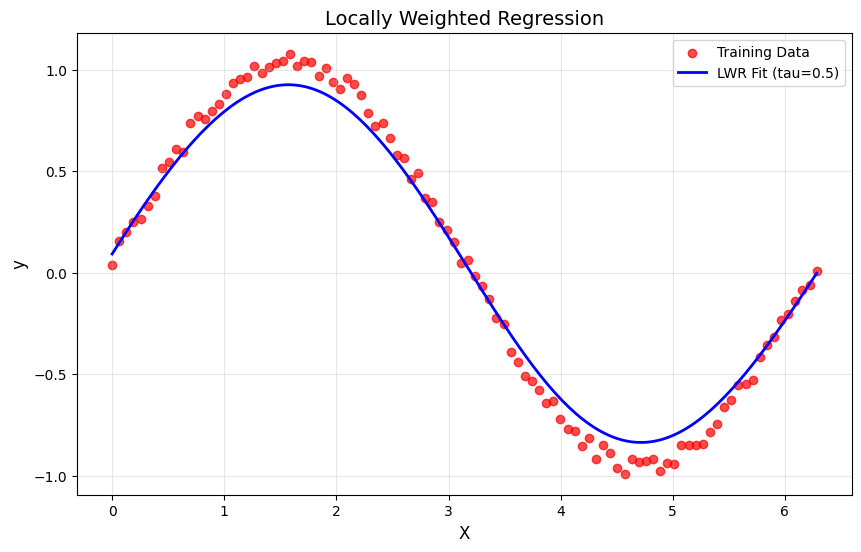

In [ ]:
#LAB_6
import numpy as np
import matplotlib.pyplot as plt
def gaussian_kernel(x, xi, tau):
    return np.exp(-np.sum((x - xi) ** 2) / (2 * tau ** 2))
def locally_weighted_regression(x, X, y, tau):
    m = X.shape[0]
    weights = np.array([gaussian_kernel(x, X[i], tau) for i in range(m)])
    W = np.diag(weights)
    X_transpose_W = X.T @ W
    theta = np.linalg.inv(X_transpose_W @ X) @ X_transpose_W @ y
    return x @ theta
np.random.seed(42)
X = np.linspace(0, 2 * np.pi, 100)
y = np.sin(X) + 0.1 * np.random.random(100)
X_bias = np.c_[np.ones(X.shape), X]
X_test = np.linspace(0, 2 * np.pi, 200)
X_test_bias = np.c_[np.ones(X_test.shape), X_test]
tau = 0.5
y_pred = np.array([locally_weighted_regression(xi, X_bias, y, tau) for xi in X_test_bias])
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='red', label='Training Data', alpha=0.7)
plt.plot(X_test, y_pred, color='blue', label=f'LWR Fit (tau={tau})', linewidth=2)
plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Locally Weighted Regression', fontsize=14)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.show()


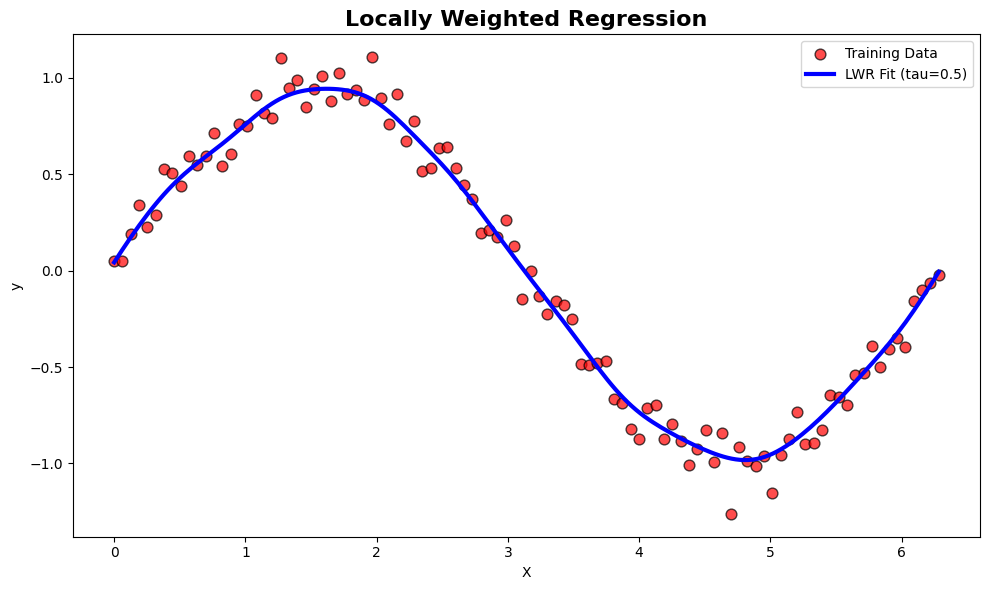

In [ ]:
#lab_6_2
import numpy as np, matplotlib.pyplot as plt
from statsmodels.nonparametric.kernel_regression import KernelReg
np.random.seed(42)
X=np.linspace(0,2*np.pi,100)
y=np.sin(X)+0.1*np.random.randn(100)
model=KernelReg(y,X,'c')
x_test=np.linspace(0,2*np.pi,200); y_pred,_=model.fit(x_test)
plt.figure(figsize=(10,6))
plt.scatter(X,y,color='red',edgecolor='black',s=60,alpha=0.7,label="Training Data")
plt.plot(x_test,y_pred,color='blue',linewidth=3,label="LWR Fit (tau=0.5)")
plt.title("Locally Weighted Regression",fontsize=16,fontweight='bold')
plt.xlabel("X"); plt.ylabel("y")
plt.legend(frameon=True)
plt.tight_layout()
plt.show()


Demonstrating Linear Regression and Polynomial Regression



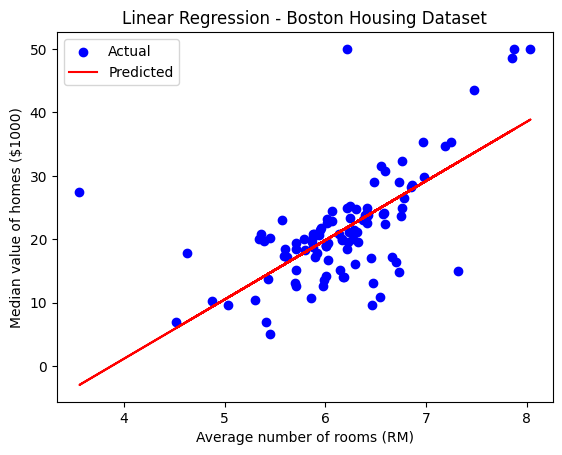

Linear Regression - Boston Housing Dataset
Mean Squared Error: 46.144775347317264
R^2 Score: 0.3707569232254778


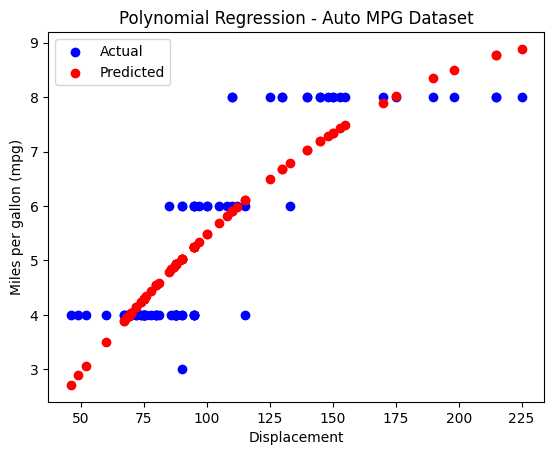

Polynomial Regression - Auto MPG Dataset
Mean Squared Error: 0.7431490557205861
R^2 Score: 0.7505650609469626


In [ ]:
#lab_7
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

def linear_regression_boston():
  url="https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
  df = pd.read_csv(url)
  X = df[["rm"]].values
  y = df["medv"].values
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)
  model = LinearRegression()
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  plt.scatter(X_test, y_test, color="blue", label="Actual")
  plt.plot(X_test, y_pred, color="red", label="Predicted")
  plt.xlabel("Average number of rooms (RM)")
  plt.ylabel("Median value of homes ($1000)")
  plt.title("Linear Regression - Boston Housing Dataset")
  plt.legend()
  plt.show()
  print("Linear Regression - Boston Housing Dataset")
  print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
  print("R^2 Score:", r2_score(y_test, y_pred))

def polynomial_regression_auto_mpg():
  url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
  column_names = ["mpg", "cylinders", "displacement", "horsepower", "weight","acceleration", "model_year", "origin"]
  data = pd.read_csv(url, sep=r'\s+', names=column_names, na_values="?")
  data = data.dropna()
  X = data["displacement"].values.reshape(-1, 1)
  y = data["mpg"].values
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)
  poly_model = make_pipeline(PolynomialFeatures(degree=2), StandardScaler(),LinearRegression())
  poly_model.fit(X_train, y_train)
  y_pred = poly_model.predict(X_test)
  plt.scatter(X_test, y_test, color="blue", label="Actual")
  plt.scatter(X_test, y_pred, color="red", label="Predicted")
  plt.xlabel("Displacement")
  plt.ylabel("Miles per gallon (mpg)")
  plt.title("Polynomial Regression - Auto MPG Dataset")
  plt.legend()
  plt.show()
  print("Polynomial Regression - Auto MPG Dataset")
  print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
  print("R^2 Score:", r2_score(y_test, y_pred))

if __name__ == "__main__":
  print("Demonstrating Linear Regression and Polynomial Regression\n")
  linear_regression_boston()
  polynomial_regression_auto_mpg()

Model trained successfully


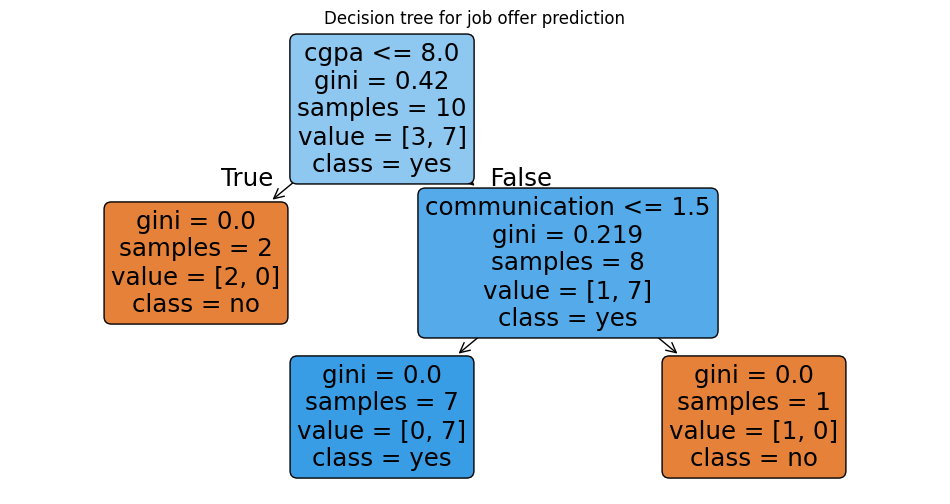

Predicted Job offer for test sample:  no


In [ ]:
#lab_8

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.preprocessing import LabelEncoder

cancer=load_breast_cancer()
X_cancer=cancer.data
y_cancer=cancer.target

bc_model=DecisionTreeClassifier(max_depth=4,random_state=42)
bc_model.fit(X_cancer,y_cancer)
print("Model trained successfully")

sample_data=pd.DataFrame({
    'cgpa':[9.2,8.5,9.0,7.5,8.2,9.1,7.8,9.3,8.4,8.6],
    'interactiveness':['yes','no','no','no','yes','yes','yes','yes','no','yes'],
    'practical_knowledge':['verygood','good','average','average','good','good','good','verygood','good','average'],
    'communication':['good','moderate','poor','good','moderate','moderate','poor','good','good','good'],
    'job_offer':['yes','yes','no','no','yes','yes','no','yes','yes','yes']
})

label_encoders={}
for column in ['interactiveness','practical_knowledge','communication','job_offer']:
  le=LabelEncoder()
  sample_data[column]=le.fit_transform(sample_data[column])
  label_encoders[column]=le

X_sample=sample_data.drop('job_offer',axis=1)
y_sample=sample_data['job_offer']

sample_model=DecisionTreeClassifier(max_depth=4,random_state=42)
sample_model.fit(X_sample,y_sample)

plt.figure(figsize=(12,6))
plot_tree(sample_model,feature_names=X_sample.columns,class_names=label_encoders['job_offer'].classes_,filled=True,rounded=True)
plt.title("Decision tree for job offer prediction")
plt.show()

test_sample=pd.DataFrame([{
    'cgpa':6.5,
    'interactiveness':'yes',
    'practical_knowledge':'good',
    'communication':'good'
}])

for column in ['interactiveness','practical_knowledge','communication']:
  test_sample[column]=label_encoders[column].transform(test_sample[column])
prediction=sample_model.predict(test_sample)
predicted_label=label_encoders['job_offer'].inverse_transform(prediction)
print("Predicted Job offer for test sample: ",predicted_label[0])

Accuracy:89.17%

Classification ReportL 
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       1.00      0.67      0.80         3
           2       0.67      0.67      0.67         3
           3       0.43      1.00      0.60         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           6       1.00      0.67      0.80         3
           7       0.75      1.00      0.86         3
           8       1.00      1.00      1.00         3
           9       1.00      0.67      0.80         3
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      0.33      0.50         3
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         3
          15       0.75      1.00      0.86         3
          16       0.60      1.00      0

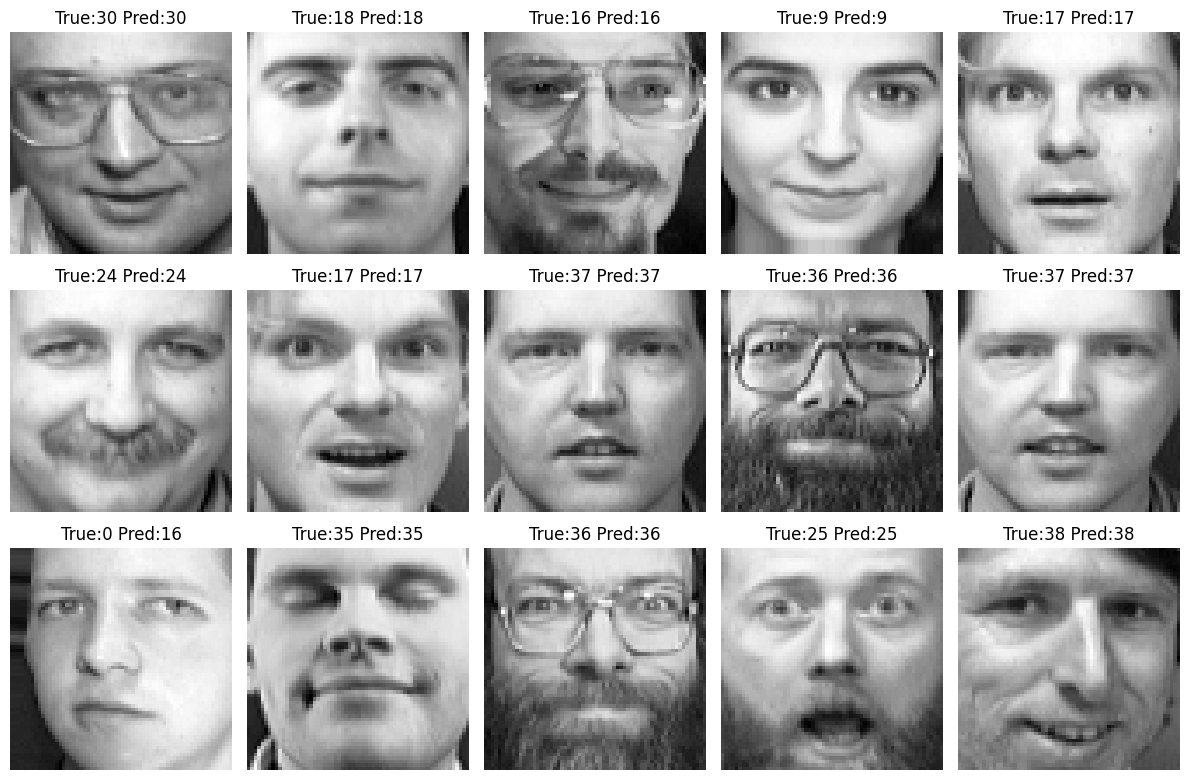

In [ ]:
#lab_9

#LAB9
import numpy as np
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import matplotlib.pyplot as plt

data=fetch_olivetti_faces(shuffle=True,random_state=42)
X=data.data
y=data.target

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

gnb=GaussianNB()

gnb.fit(X_train,y_train)

y_pred=gnb.predict(X_test)

accuracy=accuracy_score(y_test,y_pred)
print(f'Accuracy:{accuracy*100:.2f}%')

print("\nClassification ReportL ")
print(classification_report(y_test,y_pred,zero_division=1))

print("\n Confusion Matrix: ")
print(confusion_matrix(y_test,y_pred))

fig,axes=plt.subplots(3,5,figsize=(12,8))
for ax,image,label,prediction in zip(axes.ravel(),X_test,y_test,y_pred):
  ax.imshow(image.reshape(64,64),cmap=plt.cm.gray)
  ax.set_title(f"True:{label} Pred:{prediction}")
  ax.axis('off')

plt.tight_layout()
plt.show()

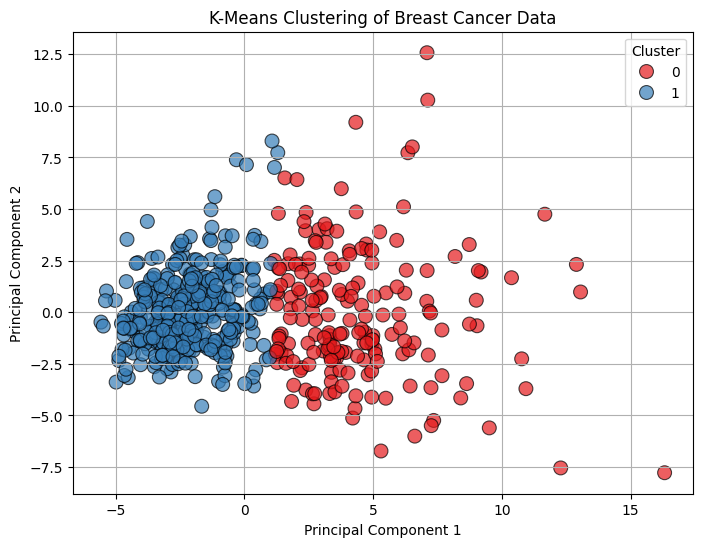

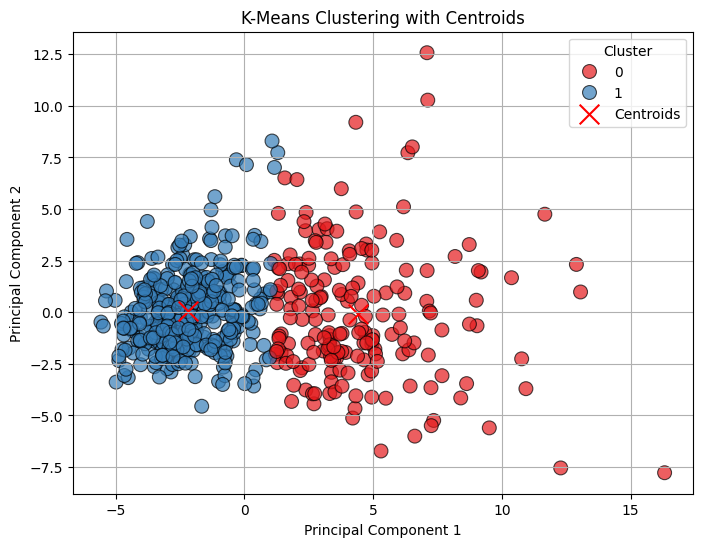

In [ ]:
#lab_10

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report

data=load_breast_cancer()
X=data.data
y=data.target

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

kmeans=KMeans(n_clusters=2,random_state=42)

y_kmeans=kmeans.fit_predict(X_scaled)

pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)

df=pd.DataFrame(X_pca,columns=['PC1','PC2'])
df['Cluster']=y_kmeans
df['True Label']=y

plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='PC1',y='PC2',hue='Cluster',palette='Set1',s=100,edgecolor='black',alpha=0.7)
plt.title('K-Means Clustering of Breast Cancer Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(data=df,x='PC1',y='PC2',hue='Cluster',palette='Set1',s=100,edgecolor='black',alpha=0.7)
centers=pca.transform(kmeans.cluster_centers_)
plt.scatter(centers[:,0],centers[:,1],c='red',marker='x',s=200,label='Centroids')
plt.title('K-Means Clustering with Centroids')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()